In [1]:
import os
import pandas as pd
from IPython.display import display
import warnings

# Ocultamos los avisos de Pandas para no ensuciar la pantalla
warnings.filterwarnings("ignore")

print("==================================================================")
print(" 🚀 MAPEO MASIVO DEFINITIVO (Juez de Fechas Anti-AM/PM)")
print("==================================================================")

base_path = "/eos/user/j/jcapotor/FBGdata/Data/pressure_setup/"
resultados = []

# =========================================================
# 1️⃣ MOTORES UNIVERSALES DE LECTURA DE FECHAS
# =========================================================
def parse_labview_smart(d, t, folder_name):
    """Deja que Pandas lea la hora como quiera, pero nosotros controlamos el Día/Mes"""
    s = f"{d.strip()} {t.strip()}"
    
    # Extraemos el Mes y Día reales del nombre de la carpeta (Ej: '20260512')
    try:
        true_m = int(folder_name[4:6])
        true_d = int(folder_name[6:8])
    except:
        true_m, true_d = None, None

    # Parseo genérico (se traga AM/PM sin quejarse) forzando el orden
    parsed_eu = pd.to_datetime(s, dayfirst=True, errors="coerce")  # Prueba como DD/MM
    parsed_us = pd.to_datetime(s, dayfirst=False, errors="coerce") # Prueba como MM/DD

    if true_m is not None:
        # Si el Europeo acierta con el nombre de tu carpeta, nos lo quedamos
        if pd.notna(parsed_eu) and parsed_eu.month == true_m and parsed_eu.day == true_d:
            return parsed_eu
        # Si el Americano acierta, nos lo quedamos
        if pd.notna(parsed_us) and parsed_us.month == true_m and parsed_us.day == true_d:
            return parsed_us

    # Fallback por si era un día loco
    if pd.notna(parsed_eu): return parsed_eu
    return parsed_us

def parse_optics_universal(d, t):
    """Limpia la fecha de Optics11 y traduce los meses del español al inglés"""
    d = d.strip().lower().replace(".", "")
    t = t.strip()
    
    es_to_en = {"ene": "jan", "feb": "feb", "mar": "mar", "abr": "apr", 
                "may": "may", "jun": "jun", "jul": "jul", "ago": "aug", 
                "sep": "sep", "oct": "oct", "nov": "nov", "dic": "dec"}
                
    for es, en in es_to_en.items():
        if es in d:
            d = d.replace(es, en)
            break
            
    if "." in t:
        parts = t.split(".")
        t = parts[0] + "." + "".join(filter(str.isdigit, parts[1]))[:6]
        s = f"{d.title()} {t}"
        parsed = pd.to_datetime(s, format="%d-%b-%Y %H:%M:%S.%f", errors="coerce")
    else:
        s = f"{d.title()} {t}"
        parsed = pd.to_datetime(s, format="%d-%b-%Y %H:%M:%S", errors="coerce")
        
    if pd.isna(parsed):
        parsed = pd.to_datetime(s, errors="coerce")
    return parsed

# =========================================================
# 2️⃣ BUCLE MASIVO 
# =========================================================
carpetas = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))])
print(f"📁 Analizando {len(carpetas)} carpetas de ensayo...\n")

for folder in carpetas:
    folder_path = os.path.join(base_path, folder)
    
    all_files = [f for f in os.listdir(folder_path) if not f.startswith('.')]
    temp_files = sorted([f for f in all_files if 'temp' in f.lower() and f.lower().endswith('.txt')])
    peak_files = sorted([f for f in all_files if 'peak' in f.lower() and f.lower().endswith('.txt')])
    
    if not temp_files or not peak_files:
        continue
        
    temp_path = os.path.join(folder_path, temp_files[0])
    peak_path = os.path.join(folder_path, peak_files[0])

    t_temp = pd.NaT
    t_peak = pd.NaT

    # --- Extraer LabVIEW ---
    try:
        with open(temp_path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) >= 2 and "/" in parts[0]:
                    t_temp = parse_labview_smart(parts[0], parts[1], folder)
                    break 
    except Exception:
        pass

    # --- Extraer Optics11 ---
    try:
        with open(peak_path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) >= 1:
                    col0 = parts[0].strip()
                    col1 = parts[1].strip() if len(parts) > 1 else ""
                    
                    if "-" in col0 and ":" in col0 and " " in col0:
                        d, t = col0.split(" ", 1)
                        t_peak = parse_optics_universal(d, t)
                        if pd.notna(t_peak): break
                        
                    elif "-" in col0 and ":" in col1:
                        t_peak = parse_optics_universal(col0, col1)
                        if pd.notna(t_peak): break
    except Exception:
        pass

    # --- Diagnóstico ---
    if pd.notna(t_temp) and pd.notna(t_peak):
        diff = t_peak - t_temp
        total_secs = diff.total_seconds()
        
        signo = "+" if total_secs >= 0 else "-"
        abs_secs = abs(total_secs)
        dias = int(abs_secs // 86400)
        horas = int((abs_secs % 86400) // 3600)
        minutos = int((abs_secs % 3600) // 60)
        segundos = abs_secs % 60
        
        if dias > 0:
            texto_bonito = f"{signo}{dias}d {horas:02d}:{minutos:02d}:{segundos:05.2f}"
        else:
            texto_bonito = f"{signo}{horas:02d}:{minutos:02d}:{segundos:05.2f}"
        
        resultados.append({
            "Directorio_Fecha": folder,
            "Inicio_LabVIEW_Temp": t_temp,
            "Inicio_Optics_Picos": t_peak,
            "Desfase_Formateado": texto_bonito,
            "Desfase_Segundos": total_secs
        })

# ==========================================
# 3️⃣ VISUALIZACIÓN DEL DATAFRAME
# ==========================================
if resultados:
    df_desfases = pd.DataFrame(resultados)
    df_desfases = df_desfases.sort_values("Directorio_Fecha").reset_index(drop=True)
    
    print(f"\n🏆 Escaneo completado. Se han rescatado {len(df_desfases)} ensayos válidos.")
    print("\n📊 DATAFRAME DE DESFASES TEMPORALES:")
    display(df_desfases)
    
    df_normales = df_desfases[df_desfases["Desfase_Segundos"].abs() < 86400] 
    if not df_normales.empty:
        desfase_medio = df_normales["Desfase_Segundos"].mean()
        print(f"\n💡 CONCLUSIÓN ESTADÍSTICA (Descartando días con el reloj defectuoso):")
        print(f"El desfase medio del interrogador en tus ensayos es de {desfase_medio:.1f} segundos.")

else:
    print("\n⚠️ No se encontró ningún día con archivos o fechas válidas.")

 🚀 MAPEO MASIVO DEFINITIVO (Juez de Fechas Anti-AM/PM)
📁 Analizando 31 carpetas de ensayo...


🏆 Escaneo completado. Se han rescatado 24 ensayos válidos.

📊 DATAFRAME DE DESFASES TEMPORALES:


 🚀 MAPEO MASIVO DEFINITIVO (Juez de Fechas Anti-AM/PM)
📁 Analizando 31 carpetas de ensayo...


🏆 Escaneo completado. Se han rescatado 24 ensayos válidos.

📊 DATAFRAME DE DESFASES TEMPORALES:


,Directorio_Fecha,Inicio_LabVIEW_Temp,Inicio_Optics_Picos,Desfase_Formateado,Desfase_Segundos
0,20240910,2024-09-10 12:20:54,2024-09-10 14:49:08.414596,+02:28:14.41,8.894415e+03
1,20240925,2024-09-25 11:55:07,2000-01-01 02:00:54.340362,-9034d 09:54:12.66,-7.805733e+08
2,20240926,2024-09-26 10:29:42,2024-09-26 11:08:56.237677,+00:39:14.24,2.354238e+03
3,20240930,2024-09-30 09:15:16,2024-09-30 10:58:38.008185,+01:43:22.01,6.202008e+03
4,20241001,2024-10-01 08:01:56,2024-10-01 08:59:00.990756,+00:57:04.99,3.424991e+03
5,20250227,2025-02-27 11:29:57,2021-11-19 19:10:42.673641,-1195d 16:19:14.33,-1.033068e+08
6,20250228,2025-02-28 12:35:18,2021-11-20 19:18:48.364740,-1195d 17:16:29.64,-1.033102e+08
7,20250310,2025-03-10 12:10:25,2025-03-10 13:10:34.725038,+01:00:09.73,3.609725e+03
8,20250515,2025-05-15 10:45:13,2025-05-15 11:13:37.651806,+00:28:24.65,1.704652e+03
9,20260202,2026-02-02 11:50:17,2026-02-02 11:50:48.937931,+00:00:31.94,3.193793e+01


 🚀 MAPEO MASIVO DEFINITIVO (Juez de Fechas Anti-AM/PM)
📁 Analizando 31 carpetas de ensayo...


🏆 Escaneo completado. Se han rescatado 24 ensayos válidos.

📊 DATAFRAME DE DESFASES TEMPORALES:


,Directorio_Fecha,Inicio_LabVIEW_Temp,Inicio_Optics_Picos,Desfase_Formateado,Desfase_Segundos
0,20240910,2024-09-10 12:20:54,2024-09-10 14:49:08.414596,+02:28:14.41,8.894415e+03
1,20240925,2024-09-25 11:55:07,2000-01-01 02:00:54.340362,-9034d 09:54:12.66,-7.805733e+08
2,20240926,2024-09-26 10:29:42,2024-09-26 11:08:56.237677,+00:39:14.24,2.354238e+03
3,20240930,2024-09-30 09:15:16,2024-09-30 10:58:38.008185,+01:43:22.01,6.202008e+03
4,20241001,2024-10-01 08:01:56,2024-10-01 08:59:00.990756,+00:57:04.99,3.424991e+03
5,20250227,2025-02-27 11:29:57,2021-11-19 19:10:42.673641,-1195d 16:19:14.33,-1.033068e+08
6,20250228,2025-02-28 12:35:18,2021-11-20 19:18:48.364740,-1195d 17:16:29.64,-1.033102e+08
7,20250310,2025-03-10 12:10:25,2025-03-10 13:10:34.725038,+01:00:09.73,3.609725e+03
8,20250515,2025-05-15 10:45:13,2025-05-15 11:13:37.651806,+00:28:24.65,1.704652e+03
9,20260202,2026-02-02 11:50:17,2026-02-02 11:50:48.937931,+00:00:31.94,3.193793e+01



💡 CONCLUSIÓN ESTADÍSTICA (Descartando días con el reloj defectuoso):
El desfase medio del interrogador en tus ensayos es de 1372.1 segundos.


## Alineamiento avanzado: pruebas múltiples
Se añaden funciones para:
- Suavizado Savitzky-Golay y derivada
- Correlación por FFT y correlación clásica
- Ajuste parabólico del pico de correlación para sub-muestra
- Emparejado de picos (find_peaks) y consenso entre métodos
Ejecuta la celda siguiente para calcular lags más finos y una tabla diagnóstica.

In [2]:
from scipy.signal import savgol_filter, find_peaks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft

def _parabolic_subsample(corr):
    imax = np.argmax(corr)
    if imax<=0 or imax>=len(corr)-1:
        return imax, 0.0
    y0, y1, y2 = corr[imax-1], corr[imax], corr[imax+1]
    denom = (y0 - 2*y1 + y2)
    if denom == 0:
        return imax, 0.0
    delta = 0.5 * (y0 - y2) / denom
    return imax, delta

def fft_correlation(x, y):
    n = len(x)
    X = fft(x, n=2*n)
    Y = fft(y, n=2*n)
    corr = ifft(X * np.conjugate(Y)).real
    corr = np.concatenate((corr[-(n-1):], corr[:n]))
    lags = np.arange(-n+1, n)
    return corr, lags

def estimate_lags(df_t_filt, df_p_filt, rtd_objetivo, active_wav, horas_ventana, desfase_bruto, plot=False):
    t_min = df_t_filt['Time_Datetime'].min()
    t_max = t_min + pd.Timedelta(hours=horas_ventana)
    time_grid = pd.date_range(start=t_min, end=t_max, freq='1s')
    grid_sec = time_grid.astype('int64') / 1e9

    t_num, t_idx = np.unique(df_t_filt['Time_Datetime'].astype('int64').values, return_index=True)
    t_val = df_t_filt[rtd_objetivo].values[t_idx].astype(float)
    p_num, p_idx = np.unique(df_p_filt['Time_Bruto'].astype('int64').values, return_index=True)
    p_val = df_p_filt[active_wav].values[p_idx].astype(float)
    t_num = t_num / 1e9; p_num = p_num / 1e9

    temp_interp = np.interp(grid_sec, t_num, t_val)
    peak_interp = np.interp(grid_sec, p_num, p_val)

    results = {}

    try:
        win = 11 if len(temp_interp) >= 11 else (len(temp_interp)//2*2+1)
        if win < 5: win = 5
        t_s = savgol_filter(temp_interp, win, 3)
        p_s = savgol_filter(peak_interp, win, 3)
        t_d = savgol_filter(temp_interp, win, 3, deriv=1, delta=1.0)
        p_d = savgol_filter(peak_interp, win, 3, deriv=1, delta=1.0)
        t_dn = (t_d - np.mean(t_d)) / (np.std(t_d) + 1e-12)
        p_dn = (p_d - np.mean(p_d)) / (np.std(p_d) + 1e-12)
        corr = np.correlate(t_dn, p_dn, mode='full')
        lags = np.arange(-len(t_dn)+1, len(t_dn))
        imax, delta = _parabolic_subsample(corr)
        best_lag_sg = lags[imax] + delta
        results['savgol_deriv_lag_s'] = best_lag_sg
        results['savgol_deriv_corrmax'] = np.max(corr)
    except Exception as e:
        results['savgol_deriv_lag_s'] = np.nan
        results['savgol_deriv_corrmax'] = np.nan
        print('SG method error:', e)

    try:
        t_nm = (temp_interp - np.mean(temp_interp)) / (np.std(temp_interp) + 1e-12)
        p_nm = (peak_interp - np.mean(peak_interp)) / (np.std(peak_interp) + 1e-12)
        corr_fft, lags_fft = fft_correlation(t_nm, p_nm)
        imax, delta = _parabolic_subsample(corr_fft)
        best_lag_fft = lags_fft[imax] + delta
        results['fft_lag_s'] = best_lag_fft
        results['fft_corrmax'] = np.max(corr_fft)
    except Exception as e:
        results['fft_lag_s'] = np.nan
        results['fft_corrmax'] = np.nan
        print('FFT method error:', e)

    try:
        peaks_t, _ = find_peaks(t_s if 't_s' in locals() else temp_interp, height=None, distance=5)
        peaks_p, _ = find_peaks(p_s if 'p_s' in locals() else peak_interp, height=None, distance=5)
        if len(peaks_t)>0 and len(peaks_p)>0:
            t_peaks_sec = grid_sec[peaks_t]
            p_peaks_sec = grid_sec[peaks_p]
            diffs = []
            for tt in t_peaks_sec:
                idx = np.argmin(np.abs(p_peaks_sec - tt))
                diffs.append(p_peaks_sec[idx] - tt)
            med = np.median(diffs)
            results['peaks_med_lag_s'] = med
            results['n_peaks_t'] = len(peaks_t)
            results['n_peaks_p'] = len(peaks_p)
        else:
            results['peaks_med_lag_s'] = np.nan
            results['n_peaks_t'] = len(peaks_t)
            results['n_peaks_p'] = len(peaks_p)
    except Exception as e:
        results['peaks_med_lag_s'] = np.nan
        print('Peaks method error:', e)

    lags = []
    for k in ['savgol_deriv_lag_s','fft_lag_s','peaks_med_lag_s']:
        v = results.get(k, np.nan)
        if np.isfinite(v): lags.append(v)
    if lags:
        results['consensus_lag_s'] = float(np.median(lags))
    else:
        results['consensus_lag_s'] = np.nan

    if plot:
        plt.figure(figsize=(10,4))
        plt.plot(time_grid, temp_interp, label='Temp (interp)', alpha=0.6)
        plt.plot(time_grid, peak_interp, label='Peak (interp)', alpha=0.6)
        if np.isfinite(results.get('consensus_lag_s')):
            shift = pd.Timedelta(seconds=results['consensus_lag_s'])
            plt.plot(time_grid + shift, peak_interp, '--', label=f'Peak shifted {results['consensus_lag_s']:.2f}s')
        plt.legend(); plt.tight_layout(); plt.show()

    return results

resultados_avanzados = []
for i, row in df_filtrado.iterrows():
    folder = row['Directorio_Fecha']
    desfase_bruto = row['Desfase_Segundos']
    folder_path = os.path.join(base_path, folder)
    all_files = [f for f in os.listdir(folder_path) if not f.startswith('.')]
    temp_files = sorted([f for f in all_files if 'temp' in f.lower() and f.lower().endswith('.txt')])
    peak_files = sorted([f for f in all_files if 'peak' in f.lower() and f.lower().endswith('.txt')])
    if not temp_files or not peak_files:
        continue
    df_t = pd.read_csv(os.path.join(folder_path, temp_files[0]), sep='	', header=None, on_bad_lines='skip')
    df_t = df_t.iloc[::2].copy()
    headers_temp = ['Date','Time','RTD-1','RTD-2','RTD-3','RTD-4','RTD-5','RTD-6','RTD-7','RTD-8']
    df_t.columns = headers_temp[:len(df_t.columns)]
    dt_str = df_t['Date'].astype(str).str.strip() + ' ' + df_t['Time'].astype(str).str.strip()
    true_m = int(folder[4:6])
    parsed_eu = pd.to_datetime(dt_str, dayfirst=True, errors='coerce')
    parsed_us = pd.to_datetime(dt_str, dayfirst=False, errors='coerce')
    df_t['Time_Datetime'] = parsed_eu if (not parsed_eu.isna().all() and parsed_eu.iloc[0].month==true_m) else parsed_us
    df_t = df_t.dropna(subset=['Time_Datetime']).sort_values('Time_Datetime')
    df_t[rtd_objetivo] = pd.to_numeric(df_t[rtd_objetivo], errors='coerce')
    df_t = df_t[(df_t[rtd_objetivo]>10)&(df_t[rtd_objetivo]<350)]
    df_p = pd.read_csv(os.path.join(folder_path, peak_files[0]), sep='	', header=None, on_bad_lines='skip')
    idx_s = np.arange(0, len(df_p), 20)
    idx_p = idx_s + 1
    idx_p = idx_p[idx_p < len(df_p)]
    df_p = df_p.iloc[np.sort(np.concatenate([idx_s, idx_p]))].copy().reset_index(drop=True)
    col0, col1 = df_p[0].astype(str).str.strip(), df_p[1].astype(str).str.strip()
    is_merged = col0.str.contains(':') & col0.str.contains('-')
    date_part = np.where(is_merged, col0.str.split(' ').str[0], col0)
    time_part = np.where(is_merged, col0.str.split(' ').str[1].str.split('.').str[0], col1.str.split('.').str[0])
    date_part = pd.Series(date_part).str.lower().str.replace('.', '', regex=False)
    for es, en in {'ene':'jan','feb':'feb','mar':'mar','abr':'apr','may':'may','jun':'jun','jul':'jul','ago':'aug','sep':'sep','oct':'oct','nov':'nov','dic':'dec'}.items():
        date_part = date_part.str.replace(es, en, regex=False)
    dt_str_p = date_part.str.title() + ' ' + pd.Series(time_part)
    df_p['Time_Datetime'] = pd.to_datetime(dt_str_p, format='%d-%b-%Y %H:%M:%S', errors='coerce')
    if df_p['Time_Datetime'].isna().all(): df_p['Time_Datetime'] = pd.to_datetime(dt_str_p, errors='coerce')
    df_p[active_wav] = pd.to_numeric(df_p[8], errors='coerce')
    df_p = df_p.groupby(df_p.index // 2).agg({'Time_Datetime':'first', active_wav:'mean'})
    df_p = df_p.dropna(subset=['Time_Datetime', active_wav]).sort_values('Time_Datetime')
    df_p = df_p[(df_p[active_wav]>1000)|((df_p[active_wav]>1e-6)&(df_p[active_wav]<2e-6))]
    df_p['Time_Bruto'] = df_p['Time_Datetime'] - pd.Timedelta(seconds=desfase_bruto)
    df_t_filt = df_t[(df_t['Time_Datetime']>=df_t['Time_Datetime'].min()) & (df_t['Time_Datetime']<=df_t['Time_Datetime'].min()+pd.Timedelta(hours=horas_ventana))].copy()
    df_p_filt = df_p[(df_p['Time_Bruto']>=df_t_filt['Time_Datetime'].min()) & (df_p['Time_Bruto']<=df_t_filt['Time_Datetime'].max())].copy()
    if len(df_t_filt)>30 and len(df_p_filt)>10:
        res = estimate_lags(df_t_filt, df_p_filt, rtd_objetivo, active_wav, horas_ventana, desfase_bruto, plot=False)
        res['Ensayo'] = folder
        resultados_avanzados.append(res)

df_avanz = pd.DataFrame(resultados_avanzados)
print('Resultados avanzados:')
display(df_avanz)

NameError: name 'df_filtrado' is not defined

 🔬 TEST DE CONSENSO AVANZADO (Solo 2 Ensayos)

🔄 Procesando ensayo 20260420...


 🔬 TEST DE CONSENSO AVANZADO (Solo 2 Ensayos)

🔄 Procesando ensayo 20260420...


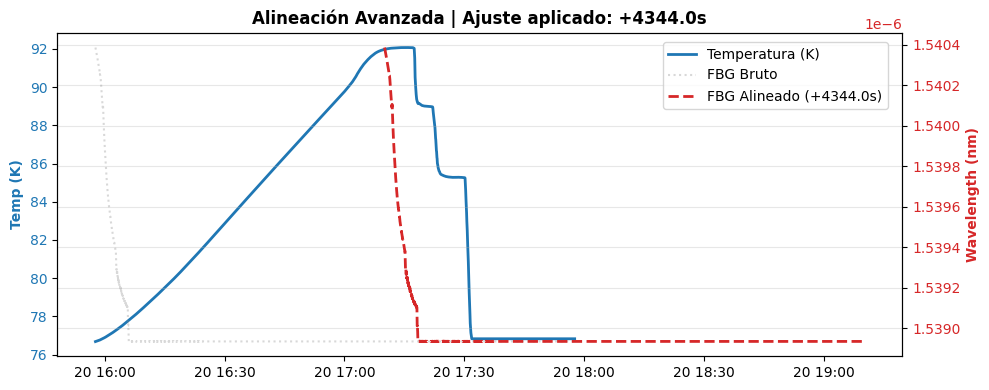

 🔬 TEST DE CONSENSO AVANZADO (Solo 2 Ensayos)

🔄 Procesando ensayo 20260420...


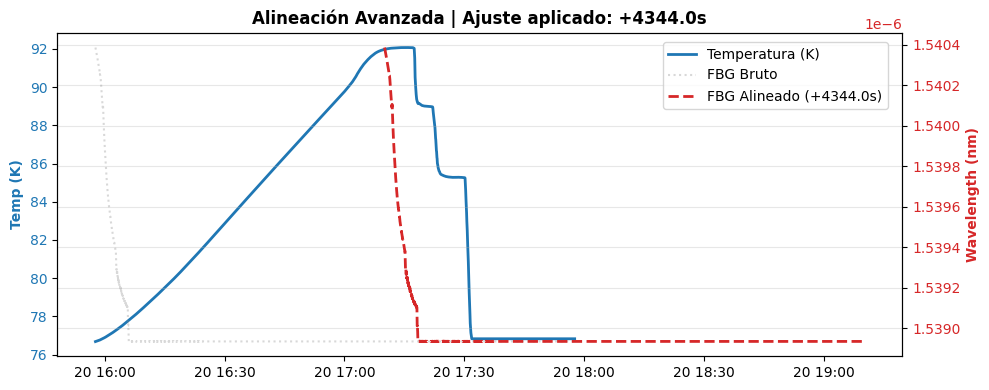


🔄 Procesando ensayo 20260512...


 🔬 TEST DE CONSENSO AVANZADO (Solo 2 Ensayos)

🔄 Procesando ensayo 20260420...


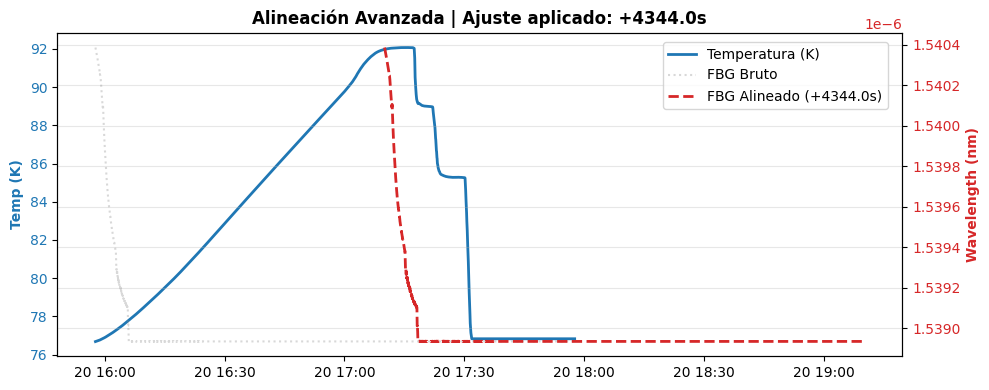


🔄 Procesando ensayo 20260512...


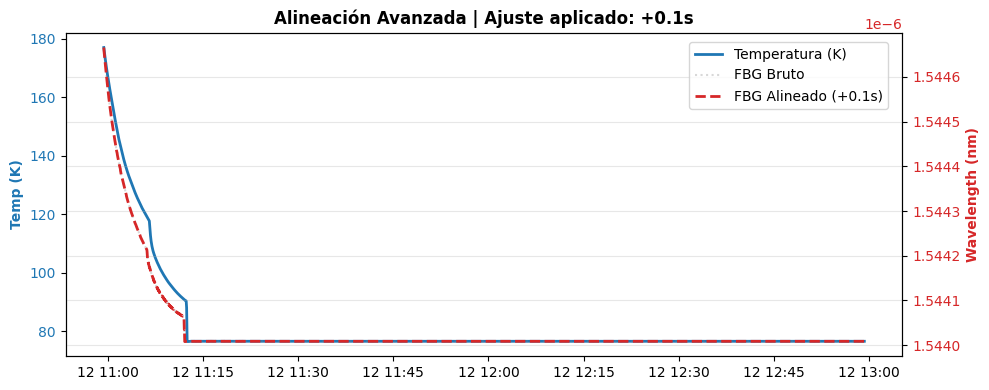


📊 RESULTADOS AVANZADOS (Consenso de Modelos):


,Ensayo,Desfase_Bruto,consensus_lag_s,Desfase_TOTAL
0,20260420,-1563.110004,4344.000511,-5907.110515
1,20260512,150.703234,0.081546,150.621688


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from numpy.fft import fft, ifft
import warnings

warnings.filterwarnings("ignore")

print("==================================================================")
print(" 🔬 TEST DE CONSENSO AVANZADO (Solo 2 Ensayos)")
print("==================================================================")

# ==========================================
# 1. FUNCIONES MATEMÁTICAS AVANZADAS
# ==========================================
def _parabolic_subsample(corr):
    imax = np.argmax(corr)
    if imax <= 0 or imax >= len(corr) - 1:
        return imax, 0.0
    y0, y1, y2 = corr[imax-1], corr[imax], corr[imax+1]
    denom = (y0 - 2*y1 + y2)
    if denom == 0:
        return imax, 0.0
    delta = 0.5 * (y0 - y2) / denom
    return imax, delta

def fft_correlation(x, y):
    n = len(x)
    X = fft(x, n=2*n)
    Y = fft(y, n=2*n)
    corr = ifft(X * np.conjugate(Y)).real
    corr = np.concatenate((corr[-(n-1):], corr[:n]))
    lags = np.arange(-n+1, n)
    return corr, lags

def estimate_lags(df_t_filt, df_p_filt, rtd_objetivo, active_wav, horas_ventana, desfase_bruto, plot=True):
    t_min = df_t_filt['Time_Datetime'].min()
    t_max = t_min + pd.Timedelta(hours=horas_ventana)
    time_grid = pd.date_range(start=t_min, end=t_max, freq='1s')
    grid_sec = time_grid.astype('int64') / 1e9

    # Extracción segura de valores únicos
    t_num, t_idx = np.unique(df_t_filt['Time_Datetime'].astype('int64').values, return_index=True)
    t_val = df_t_filt[rtd_objetivo].values[t_idx].astype(float)
    
    p_num, p_idx = np.unique(df_p_filt['Time_Bruto'].astype('int64').values, return_index=True)
    p_val = df_p_filt[active_wav].values[p_idx].astype(float)
    
    t_num = t_num / 1e9
    p_num = p_num / 1e9

    temp_interp = np.interp(grid_sec, t_num, t_val)
    peak_interp = np.interp(grid_sec, p_num, p_val)

    results = {}

    # --- MÉTODO 1: Savitzky-Golay + Correlación de Derivadas ---
    try:
        win = 11 if len(temp_interp) >= 11 else (len(temp_interp)//2*2+1)
        if win < 5: win = 5
        t_d = savgol_filter(temp_interp, win, 3, deriv=1, delta=1.0)
        p_d = savgol_filter(peak_interp, win, 3, deriv=1, delta=1.0)
        t_dn = (t_d - np.mean(t_d)) / (np.std(t_d) + 1e-12)
        p_dn = (p_d - np.mean(p_d)) / (np.std(p_d) + 1e-12)
        corr = np.correlate(t_dn, p_dn, mode='full')
        lags = np.arange(-len(t_dn)+1, len(t_dn))
        imax, delta = _parabolic_subsample(corr)
        results['savgol_deriv_lag_s'] = lags[imax] + delta
    except Exception as e:
        results['savgol_deriv_lag_s'] = np.nan

    # --- MÉTODO 2: Transformada Rápida de Fourier (FFT) ---
    try:
        t_nm = (temp_interp - np.mean(temp_interp)) / (np.std(temp_interp) + 1e-12)
        p_nm = (peak_interp - np.mean(peak_interp)) / (np.std(peak_interp) + 1e-12)
        corr_fft, lags_fft = fft_correlation(t_nm, p_nm)
        imax, delta = _parabolic_subsample(corr_fft)
        results['fft_lag_s'] = lags_fft[imax] + delta
    except Exception as e:
        results['fft_lag_s'] = np.nan

    # --- MÉTODO 3: Detección de picos en la derivada absoluta ---
    try:
        # Buscamos el momento de "máxima velocidad de cambio" (el escalón)
        peaks_t, _ = find_peaks(np.abs(t_d), height=np.max(np.abs(t_d))*0.5, distance=60)
        peaks_p, _ = find_peaks(np.abs(p_d), height=np.max(np.abs(p_d))*0.5, distance=60)
        
        if len(peaks_t) > 0 and len(peaks_p) > 0:
            # Comparamos el pico más grande de temperatura con el de luz
            t_peak = grid_sec[peaks_t[np.argmax(np.abs(t_d[peaks_t]))]]
            p_peak = grid_sec[peaks_p[np.argmax(np.abs(p_d[peaks_p]))]]
            results['peaks_med_lag_s'] = p_peak - t_peak
        else:
            results['peaks_med_lag_s'] = np.nan
    except Exception as e:
        results['peaks_med_lag_s'] = np.nan

    # --- CONSENSO ---
    lags_validos = [v for k, v in results.items() if 'lag_s' in k and np.isfinite(v) and abs(v) < len(grid_sec)*0.8]
    if lags_validos:
        results['consensus_lag_s'] = float(np.median(lags_validos))
    else:
        results['consensus_lag_s'] = 0.0

    # --- GRÁFICA DE DEBUG VISUAL ---
    if plot:
        fig, ax1 = plt.subplots(figsize=(10, 4))
        color_t = 'tab:blue'
        ax1.plot(time_grid, temp_interp, label='Temperatura (K)', color=color_t, linewidth=2)
        ax1.set_ylabel('Temp (K)', color=color_t, fontweight='bold')
        ax1.tick_params(axis='y', labelcolor=color_t)

        ax2 = ax1.twinx()
        color_p = 'tab:red'
        ax2.plot(time_grid, peak_interp, label='FBG Bruto', color='gray', alpha=0.3, linestyle=':')
        
        shift_s = results['consensus_lag_s']
        shift_td = pd.Timedelta(seconds=shift_s)
        
        ax2.plot(time_grid + shift_td, peak_interp, label=f'FBG Alineado ({shift_s:+.1f}s)', color=color_p, linestyle='--', linewidth=2)
        ax2.set_ylabel('Wavelength (nm)', color=color_p, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor=color_p)

        plt.title(f"Alineación Avanzada | Ajuste aplicado: {shift_s:+.1f}s", fontweight='bold')
        fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return results

# ==========================================
# 2. BUCLE PARA 2 ENSAYOS DE PRUEBA
# ==========================================
base_path = "/eos/user/j/jcapotor/FBGdata/Data/pressure_setup/"
rtd_objetivo = "RTD-8"
active_wav = "Wav_Ch1"
horas_ventana = 2.0

# Elegimos 2 días: uno con mucho desfase y otro perfecto
dias_prueba = ["20260420", "20260512"]

if 'df_desfases' not in locals() or df_desfases.empty:
    raise ValueError("⚠️ Ejecuta primero la celda que crea 'df_desfases'.")

df_filtrado = df_desfases[df_desfases["Directorio_Fecha"].isin(dias_prueba)].reset_index(drop=True)
resultados_avanzados = []

for i, row in df_filtrado.iterrows():
    folder = row['Directorio_Fecha']
    desfase_bruto = row['Desfase_Segundos']
    folder_path = os.path.join(base_path, folder)
    
    print(f"\n🔄 Procesando ensayo {folder}...")
    
    all_files = [f for f in os.listdir(folder_path) if not f.startswith('.')]
    temp_files = sorted([f for f in all_files if 'temp' in f.lower() and f.lower().endswith('.txt')])
    peak_files = sorted([f for f in all_files if 'peak' in f.lower() and f.lower().endswith('.txt')])
    
    if not temp_files or not peak_files:
        continue
        
    # LabVIEW (Aviso: corregido sep='\t')
    df_t = pd.read_csv(os.path.join(folder_path, temp_files[0]), sep='\t', header=None, on_bad_lines='skip')
    df_t = df_t.iloc[::2].copy()
    headers_temp = ['Date','Time','RTD-1','RTD-2','RTD-3','RTD-4','RTD-5','RTD-6','RTD-7','RTD-8']
    df_t.columns = headers_temp[:len(df_t.columns)]
    dt_str = df_t['Date'].astype(str).str.strip() + ' ' + df_t['Time'].astype(str).str.strip()
    true_m = int(folder[4:6])
    parsed_eu = pd.to_datetime(dt_str, dayfirst=True, errors='coerce')
    parsed_us = pd.to_datetime(dt_str, dayfirst=False, errors='coerce')
    df_t['Time_Datetime'] = parsed_eu if (not parsed_eu.isna().all() and parsed_eu.iloc[0].month==true_m) else parsed_us
    df_t = df_t.dropna(subset=['Time_Datetime']).sort_values('Time_Datetime')
    df_t[rtd_objetivo] = pd.to_numeric(df_t[rtd_objetivo], errors='coerce')
    df_t = df_t[(df_t[rtd_objetivo]>10)&(df_t[rtd_objetivo]<350)]
    
    # Optics11
    df_p = pd.read_csv(os.path.join(folder_path, peak_files[0]), sep='\t', header=None, on_bad_lines='skip')
    idx_s = np.arange(0, len(df_p), 20)
    idx_p = idx_s + 1
    idx_p = idx_p[idx_p < len(df_p)]
    df_p = df_p.iloc[np.sort(np.concatenate([idx_s, idx_p]))].copy().reset_index(drop=True)
    col0, col1 = df_p[0].astype(str).str.strip(), df_p[1].astype(str).str.strip()
    is_merged = col0.str.contains(':') & col0.str.contains('-')
    date_part = np.where(is_merged, col0.str.split(' ').str[0], col0)
    time_part = np.where(is_merged, col0.str.split(' ').str[1].str.split('.').str[0], col1.str.split('.').str[0])
    date_part = pd.Series(date_part).str.lower().str.replace('.', '', regex=False)
    for es, en in {'ene':'jan','feb':'feb','mar':'mar','abr':'apr','may':'may','jun':'jun','jul':'jul','ago':'aug','sep':'sep','oct':'oct','nov':'nov','dic':'dec'}.items():
        date_part = date_part.str.replace(es, en, regex=False)
    dt_str_p = date_part.str.title() + ' ' + pd.Series(time_part)
    df_p['Time_Datetime'] = pd.to_datetime(dt_str_p, format='%d-%b-%Y %H:%M:%S', errors='coerce')
    if df_p['Time_Datetime'].isna().all(): df_p['Time_Datetime'] = pd.to_datetime(dt_str_p, errors='coerce')
    df_p[active_wav] = pd.to_numeric(df_p[8], errors='coerce')
    df_p = df_p.groupby(df_p.index // 2).agg({'Time_Datetime':'first', active_wav:'mean'})
    df_p = df_p.dropna(subset=['Time_Datetime', active_wav]).sort_values('Time_Datetime')
    df_p = df_p[(df_p[active_wav]>1000)|((df_p[active_wav]>1e-6)&(df_p[active_wav]<2e-6))]
    
    df_p['Time_Bruto'] = df_p['Time_Datetime'] - pd.Timedelta(seconds=desfase_bruto)
    
    # Recorte a ventana de 2 horas
    t0 = df_t['Time_Datetime'].min()
    t1 = t0 + pd.Timedelta(hours=horas_ventana)
    df_t_filt = df_t[(df_t['Time_Datetime'] >= t0) & (df_t['Time_Datetime'] <= t1)].copy()
    
    # Damos MUCHO margen a df_p por si el evento está muy desfasado (+/- 2 horas de margen)
    df_p_filt = df_p[(df_p['Time_Bruto'] >= t0 - pd.Timedelta(hours=2)) & (df_p['Time_Bruto'] <= t1 + pd.Timedelta(hours=2))].copy()
    
    if len(df_t_filt) > 30 and len(df_p_filt) > 10:
        res = estimate_lags(df_t_filt, df_p_filt, rtd_objetivo, active_wav, horas_ventana, desfase_bruto, plot=True)
        res['Ensayo'] = folder
        res['Desfase_Bruto'] = desfase_bruto
        res['Desfase_TOTAL'] = desfase_bruto - res['consensus_lag_s']
        resultados_avanzados.append(res)

df_avanz = pd.DataFrame(resultados_avanzados)
print('\n📊 RESULTADOS AVANZADOS (Consenso de Modelos):')
display(df_avanz[["Ensayo", "Desfase_Bruto", "consensus_lag_s", "Desfase_TOTAL"]])

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import savgol_filter, find_peaks
from numpy.fft import fft, ifft
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

print("==================================================================")
print(" 🔬 DEBUG VISUAL: CONCATENACIÓN + CONSENSO (Solo 2 Ensayos)")
print("==================================================================")

# ==========================================
# 1. FUNCIONES MATEMÁTICAS AVANZADAS
# ==========================================
def _parabolic_subsample(corr):
    imax = np.argmax(corr)
    if imax <= 0 or imax >= len(corr) - 1: return imax, 0.0
    y0, y1, y2 = corr[imax-1], corr[imax], corr[imax+1]
    denom = (y0 - 2*y1 + y2)
    if denom == 0: return imax, 0.0
    delta = 0.5 * (y0 - y2) / denom
    return imax, delta

def fft_correlation(x, y):
    n = len(x)
    X = fft(x, n=2*n)
    Y = fft(y, n=2*n)
    corr = ifft(X * np.conjugate(Y)).real
    corr = np.concatenate((corr[-(n-1):], corr[:n]))
    lags = np.arange(-n+1, n)
    return corr, lags

def estimate_lags(df_t_filt, df_p_filt, rtd_objetivo, active_wav):
    # Usamos toda la ventana disponible de los datos filtrados
    t_min = df_t_filt['Time_Datetime'].min()
    t_max = df_t_filt['Time_Datetime'].max() 
    time_grid = pd.date_range(start=t_min, end=t_max, freq='1s')
    grid_sec = time_grid.astype('int64') / 1e9

    t_num, t_idx = np.unique(df_t_filt['Time_Datetime'].astype('int64').values, return_index=True)
    t_val = df_t_filt[rtd_objetivo].values[t_idx].astype(float)
    p_num, p_idx = np.unique(df_p_filt['Time_Bruto'].astype('int64').values, return_index=True)
    p_val = df_p_filt[active_wav].values[p_idx].astype(float)
    
    t_num, p_num = t_num / 1e9, p_num / 1e9
    temp_interp = np.interp(grid_sec, t_num, t_val)
    peak_interp = np.interp(grid_sec, p_num, p_val)

    results = {}

    # Savitzky-Golay
    try:
        win = 11 if len(temp_interp) >= 11 else (len(temp_interp)//2*2+1)
        if win < 5: win = 5
        t_d = savgol_filter(temp_interp, win, 3, deriv=1, delta=1.0)
        p_d = savgol_filter(peak_interp, win, 3, deriv=1, delta=1.0)
        t_dn = (t_d - np.mean(t_d)) / (np.std(t_d) + 1e-12)
        p_dn = (p_d - np.mean(p_d)) / (np.std(p_d) + 1e-12)
        corr = np.correlate(t_dn, p_dn, mode='full')
        lags = np.arange(-len(t_dn)+1, len(t_dn))
        imax, delta = _parabolic_subsample(corr)
        results['savgol_deriv_lag_s'] = lags[imax] + delta
    except: results['savgol_deriv_lag_s'] = np.nan

    # FFT
    try:
        t_nm = (temp_interp - np.mean(temp_interp)) / (np.std(temp_interp) + 1e-12)
        p_nm = (peak_interp - np.mean(peak_interp)) / (np.std(peak_interp) + 1e-12)
        corr_fft, lags_fft = fft_correlation(t_nm, p_nm)
        imax, delta = _parabolic_subsample(corr_fft)
        results['fft_lag_s'] = lags_fft[imax] + delta
    except: results['fft_lag_s'] = np.nan

    # Picos en valor absoluto
    try:
        peaks_t, _ = find_peaks(np.abs(t_d), height=np.max(np.abs(t_d))*0.5, distance=60)
        peaks_p, _ = find_peaks(np.abs(p_d), height=np.max(np.abs(p_d))*0.5, distance=60)
        if len(peaks_t) > 0 and len(peaks_p) > 0:
            t_peak = grid_sec[peaks_t[np.argmax(np.abs(t_d[peaks_t]))]]
            p_peak = grid_sec[peaks_p[np.argmax(np.abs(p_d[peaks_p]))]]
            results['peaks_med_lag_s'] = p_peak - t_peak
        else: results['peaks_med_lag_s'] = np.nan
    except: results['peaks_med_lag_s'] = np.nan

    lags_validos = [v for k, v in results.items() if 'lag_s' in k and np.isfinite(v) and abs(v) < len(grid_sec)*0.8]
    results['consensus_lag_s'] = float(np.median(lags_validos)) if lags_validos else 0.0

    return results

# ==========================================
# 2. BUCLE PARA 2 ENSAYOS (CON GRÁFICOS)
# ==========================================
base_path = "/eos/user/j/jcapotor/FBGdata/Data/pressure_setup/"
rtd_objetivo = "RTD-8"
active_wav = "Wav_Ch1"
horas_ventana = 4.0 # 4 horas porque ahora unimos archivos

# 🌟 SOLO DOS ENSAYOS PARA EL DEBUG
dias_objetivo = ["20260420", "20260512"]

if 'df_desfases' not in locals() or df_desfases.empty:
    raise ValueError("⚠️ Ejecuta primero la celda que crea 'df_desfases'.")

df_filtrado = df_desfases[df_desfases["Directorio_Fecha"].isin(dias_objetivo)].reset_index(drop=True)
resultados_avanzados = []

# Preparamos la figura de 1 fila x 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, row in df_filtrado.iterrows():
    folder = row['Directorio_Fecha']
    desfase_bruto = row['Desfase_Segundos']
    folder_path = os.path.join(base_path, folder)
    ax1 = axes[i]
    
    print(f"🔄 Procesando {folder} (Uniendo archivos)...")
    
    all_files = [f for f in os.listdir(folder_path) if not f.startswith('.')]
    temp_files = sorted([f for f in all_files if 'temp' in f.lower() and f.lower().endswith('.txt')])
    peak_files = sorted([f for f in all_files if 'peak' in f.lower() and f.lower().endswith('.txt')])
    
    if not temp_files or not peak_files:
        ax1.set_title(f"❌ {folder} (Faltan archivos)", color="red")
        continue
        
    try:
        # --- CARGAR Y UNIR TODOS LOS ARCHIVOS DE LABVIEW ---
        df_t_list = []
        for t_file in temp_files:
            tmp = pd.read_csv(os.path.join(folder_path, t_file), sep='\t', header=None, on_bad_lines='skip')
            tmp = tmp.iloc[::2].copy() # Diezmamos para no saturar RAM
            df_t_list.append(tmp)
        df_t = pd.concat(df_t_list, ignore_index=True)
        
        headers_temp = ['Date','Time','RTD-1','RTD-2','RTD-3','RTD-4','RTD-5','RTD-6','RTD-7','RTD-8']
        df_t.columns = headers_temp[:len(df_t.columns)]
        dt_str = df_t['Date'].astype(str).str.strip() + ' ' + df_t['Time'].astype(str).str.strip()
        true_m = int(folder[4:6])
        parsed_eu = pd.to_datetime(dt_str, dayfirst=True, errors='coerce')
        parsed_us = pd.to_datetime(dt_str, dayfirst=False, errors='coerce')
        df_t['Time_Datetime'] = parsed_eu if (not parsed_eu.isna().all() and parsed_eu.iloc[0].month==true_m) else parsed_us
        df_t = df_t.dropna(subset=['Time_Datetime']).sort_values('Time_Datetime').reset_index(drop=True)
        df_t[rtd_objetivo] = pd.to_numeric(df_t[rtd_objetivo], errors='coerce')
        df_t = df_t[(df_t[rtd_objetivo]>10)&(df_t[rtd_objetivo]<350)]
        
        # --- CARGAR Y UNIR TODOS LOS ARCHIVOS DE OPTICS11 ---
        df_p_list = []
        for p_file in peak_files:
            tmp = pd.read_csv(os.path.join(folder_path, p_file), sep='\t', header=None, on_bad_lines='skip')
            idx_s = np.arange(0, len(tmp), 20)
            idx_p = idx_s + 1
            idx_p = idx_p[idx_p < len(tmp)]
            tmp = tmp.iloc[np.sort(np.concatenate([idx_s, idx_p]))].copy()
            df_p_list.append(tmp)
        df_p = pd.concat(df_p_list, ignore_index=True).reset_index(drop=True)
        
        col0, col1 = df_p[0].astype(str).str.strip(), df_p[1].astype(str).str.strip()
        is_merged = col0.str.contains(':') & col0.str.contains('-')
        date_part = np.where(is_merged, col0.str.split(' ').str[0], col0)
        time_part = np.where(is_merged, col0.str.split(' ').str[1].str.split('.').str[0], col1.str.split('.').str[0])
        date_part = pd.Series(date_part).str.lower().str.replace('.', '', regex=False)
        for es, en in {'ene':'jan','feb':'feb','mar':'mar','abr':'apr','may':'may','jun':'jun','jul':'jul','ago':'aug','sep':'sep','oct':'oct','nov':'nov','dic':'dec'}.items():
            date_part = date_part.str.replace(es, en, regex=False)
        dt_str_p = date_part.str.title() + ' ' + pd.Series(time_part)
        df_p['Time_Datetime'] = pd.to_datetime(dt_str_p, format='%d-%b-%Y %H:%M:%S', errors='coerce')
        if df_p['Time_Datetime'].isna().all(): df_p['Time_Datetime'] = pd.to_datetime(dt_str_p, errors='coerce')
        df_p[active_wav] = pd.to_numeric(df_p[8], errors='coerce')
        
        # Agrupar S/P
        df_p = df_p.groupby(df_p.index // 2).agg({'Time_Datetime':'first', active_wav:'mean'})
        df_p = df_p.dropna(subset=['Time_Datetime', active_wav]).sort_values('Time_Datetime').reset_index(drop=True)
        df_p = df_p[(df_p[active_wav]>1000)|((df_p[active_wav]>1e-6)&(df_p[active_wav]<2e-6))]
        
        df_p['Time_Bruto'] = df_p['Time_Datetime'] - pd.Timedelta(seconds=desfase_bruto)
        
        # --- FILTRADO AMPLIO Y ALINEACIÓN ---
        t0 = df_t['Time_Datetime'].min()
        t1 = t0 + pd.Timedelta(hours=horas_ventana)
        df_t_filt = df_t[(df_t['Time_Datetime'] >= t0) & (df_t['Time_Datetime'] <= t1)].copy()
        
        # Damos +/- 2h de margen a la luz para encontrar la caída
        df_p_filt = df_p[(df_p['Time_Bruto'] >= t0 - pd.Timedelta(hours=2)) & (df_p['Time_Bruto'] <= t1 + pd.Timedelta(hours=2))].copy()
        
        if len(df_t_filt) > 30 and len(df_p_filt) > 10:
            res = estimate_lags(df_t_filt, df_p_filt, rtd_objetivo, active_wav)
            lag_consenso = res['consensus_lag_s']
            
            res['Ensayo'] = folder
            res['Desfase_Bruto'] = desfase_bruto
            res['Desfase_TOTAL_PERFECTO'] = desfase_bruto - lag_consenso
            resultados_avanzados.append(res)
            
            # --- DIBUJAR ---
            df_p_filt["Time_Perfecto"] = df_p_filt["Time_Bruto"] + pd.Timedelta(seconds=lag_consenso)
            
            color_t = "tab:blue"
            ax1.plot(df_t_filt["Time_Datetime"], df_t_filt[rtd_objetivo], color=color_t, linewidth=2, label="Temp (K)")
            ax1.set_ylabel("Temp (K)", color=color_t, fontweight='bold')
            ax1.tick_params(axis="y", labelcolor=color_t)
            
            ax2 = ax1.twinx()
            color_p = "tab:red"
            # Dibujamos cómo estaba antes de la magia (gris) y cómo queda ahora (rojo)
            ax2.plot(df_p_filt["Time_Bruto"], df_p_filt[active_wav], color='gray', alpha=0.3, linestyle=':', label="FBG Original")
            ax2.plot(df_p_filt["Time_Perfecto"], df_p_filt[active_wav], color=color_p, linestyle="--", linewidth=2, label="FBG Alineado")
            ax2.set_ylabel("Wavelength (nm)", color=color_p, fontweight='bold')
            ax2.tick_params(axis="y", labelcolor=color_p)
            
            ax1.set_title(f"{folder} | Ajuste aplicado: {lag_consenso:+.1f}s", fontsize=11, fontweight="bold", color="darkred")
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            ax1.tick_params(axis='x', rotation=30)
            ax1.grid(True, alpha=0.3)
            
            # Unificar leyendas
            lines, labels = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax2.legend(lines + lines2, labels + labels2, loc='upper right', framealpha=0.9)

        else:
            ax1.set_title(f"⚠️ {folder}: Omitido (Faltan datos)", color="orange")
            
    except Exception as e:
        ax1.set_title(f"❌ {folder}: Error ({e})", color="red")

fig.tight_layout()
plt.show()

# ==========================================
# 3. MOSTRAR TABLA DE RESULTADOS
# ==========================================
if resultados_avanzados:
    df_avanz = pd.DataFrame(resultados_avanzados)
    df_avanz = df_avanz[["Ensayo", "Desfase_Bruto", "consensus_lag_s", "Desfase_TOTAL_PERFECTO"]]
    print("\n🏆 TABLA DE CALIBRACIÓN TEMPORAL (DEBUG):")
    display(df_avanz)

ValueError: operands could not be broadcast together with shapes (40876,) (2,) (1,) 